Dataset Reference: https://drive.google.com/file/d/1cCB19GQ3Of92RAk5TVb0DPohCt1eZR6d/view?usp=sharing

Question 1: Exploratory Data Analysis (EDA) -20

**Problem Statement:**

Find the three most important factors that separate individuals who earn more than $50K annually from those who earn $50K or less

Tasks:

Perform EDA using appropriate charts and basic descriptive statistics.

Select your top 3 features and justify your choices using visual and statistical evidence.

For each selected feature, explain in simple terms why it intuitively affects income.

Rank your 3 features from most important to least important, provide why you think that ?


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv("adult_income.csv")
df.sample(6)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
29017,27,Local-gov,137629,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,80,United-States,>50K
16406,28,Self-emp-not-inc,192838,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,45,United-States,<=50K
44846,32,Federal-gov,228696,Some-college,10,Divorced,Adm-clerical,Unmarried,White,Male,0,0,40,Mexico,<=50K.
38211,30,Private,110083,Assoc-voc,11,Never-married,Craft-repair,Not-in-family,White,Female,0,0,40,United-States,<=50K.
40253,27,Private,192140,HS-grad,9,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,20,United-States,<=50K.
40762,31,Private,178615,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,<=50K.


In [ ]:
df.describe()


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


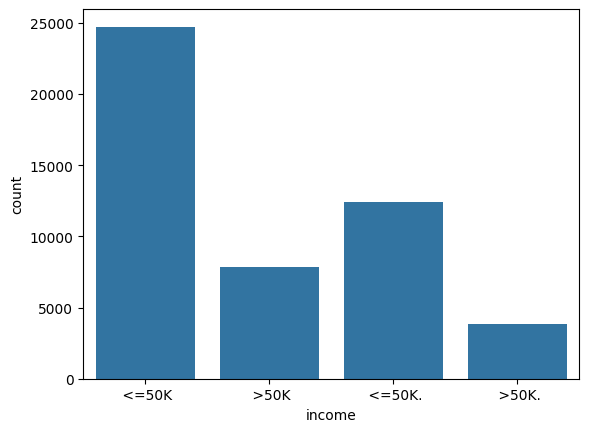

In [ ]:
sns.countplot(data=df,x='income')

plt.show()

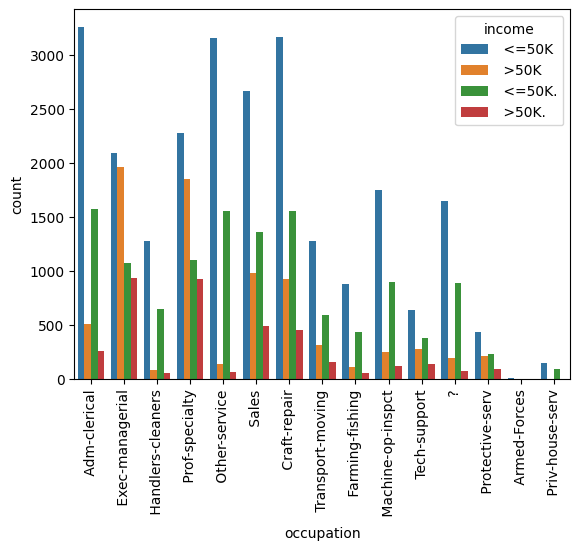

In [ ]:
sns.countplot(data=df,x='occupation',hue='income')
plt.xticks(rotation=90)
plt.show()

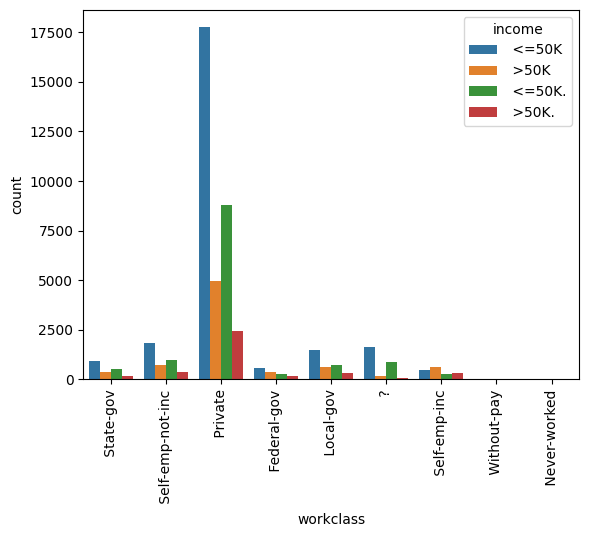

In [ ]:
sns.countplot(data=df,x='workclass',hue='income')
plt.xticks(rotation=90)
plt.show() # nai effect


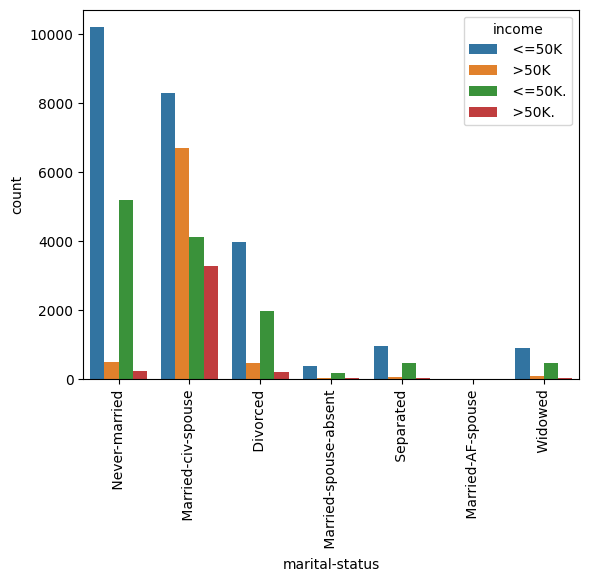

In [ ]:
sns.countplot(data=df,x='marital-status',hue='income')
plt.xticks(rotation=90)
plt.show() # nai effect

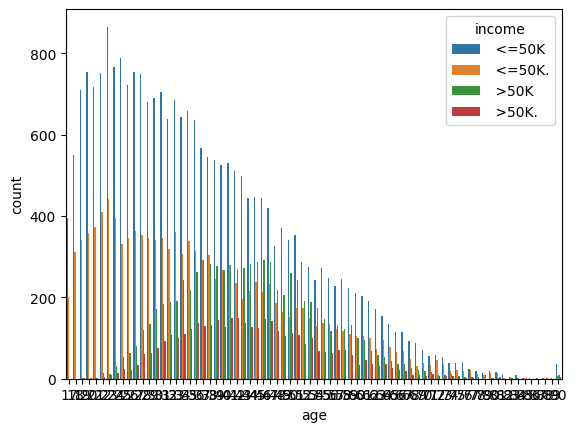

In [ ]:
sns.countplot(data=df,x='age',hue='income')

plt.show()

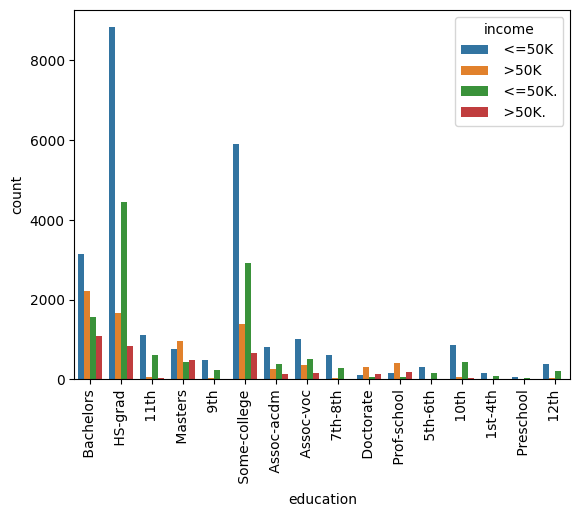

In [ ]:
sns.countplot(data=df,x='education',hue='income')
plt.xticks(rotation=90)
plt.show() # nai effect

## **top three features are occupation,age,education.........**

# **Education** – Higher educational qualifications are strongly associated with higher income levels.

# **Occupation –  Professional and managerial occupations contain a significantly larger proportion of high-income individual**s.

# Age – Individuals in higher age groups tend to earn more due to greater work experience and career advancement opportunitie

**rank:**

1.education

2.occupation

3.age


# Education creates the clearest separation between income groups and directly influences job opportunities.


#Occupation Different occupations have substantially different salary ranges.


#Age experience increases with age, but its impact is less direct than education and occupation.


#Question 2: Preprocessing Pipeline Design (Regression) - 20

**Problem Statement:**

Predicting a continuous variable requires clean, properly formatted data. You will design a preprocessing pipeline to prepare the dataset for predicting hours-per-week based on the other available features.
**Tasks:**

Design Scikit-Learn Pipelines that handles missing values, categorical feature encoding, and numerical feature scaling.

Documentation: Clearly explain what specific preprocessing steps you applied to which columns and why you chose those specific methods.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd


import warnings
warnings.filterwarnings("ignore")

In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
x= df.drop('hours-per-week', axis=1)
y = df['hours-per-week']

In [ ]:
numeric_features = x.select_dtypes(include=['int64', 'float64']).columns
categorical_features = x.select_dtypes(include=['object']).columns
numeric_features,categorical_features

(Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='object'),
 Index(['workclass', 'education', 'marital-status', 'occupation',
        'relationship', 'race', 'sex', 'native-country', 'income'],
       dtype='object'))

In [ ]:
from sklearn import preprocessing
numerical_transformer=Pipeline(steps=
                               [
                                   ('imputer',SimpleImputer(strategy='median')),
                                   ('scaler',StandardScaler())
                               ])

categorical_transformer=Pipeline(steps=
                                 [
                                   ('imputer',SimpleImputer(strategy='most_frequent')),
                                   ('onehot',OneHotEncoder(handle_unknown='ignore'))
                                 ])
preprocessing=ColumnTransformer(
    transformers=[
        ('num',numerical_transformer,numeric_features),
        ('cat',categorical_transformer,categorical_features)
    ]
)
preprocessing



ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object'))])

# **Question 3:**
#Regression Modeling & Evaluation - 20
Problem Statement:

Utilizing the preprocessing pipeline designed in Question 2, train two different regression models to predict hours-per-week and evaluate their performance.

Tasks:
Train a standard Linear Regression model using your pipeline.

Train a Stochastic Gradient Descent (SGD) Regressor model using your pipeline.

Evaluate and compare both models using R2, MAE, and MSE.

Briefly discuss which model performed better and why.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [ ]:
preprocessing.fit(x_train)
x_train_transformed=preprocessing.transform(x_train)
x_test_transformed=preprocessing.transform(x_test)

In [ ]:
modal1=Pipeline(steps=[
    ('preprocessing',preprocessing),
    ('model',LogisticRegression())
    ])

modal1


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object'))])),
                ('model', LogisticRegression())])

In [ ]:
import sklearn.linear_model as linear_model
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
lr_pipline=Pipeline(
    steps=[
        ("preprocessor",preprocessing),
        ("model",LinearRegression())
    ]
)
lr_pipline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [ ]:
lr_pipline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [ ]:


x_test_pred=lr_pipline.predict(x_test)
x_test_pred

array([39.77155919, 30.57106533, 38.58806203, ..., 46.93749874,
       45.90579797, 45.27670124])

In [ ]:
sgd_pipline=Pipeline(
    steps=[
        ("preprocessor",preprocessing),
        ("model",SGDRegressor())

    ]
)
sgd_pipline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object'))])),
                ('model', SGDRegressor())])

In [ ]:
sgd_pipline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object'))])),
                ('model', SGDRegressor())])

In [ ]:

sgd_pipline.fit(x_train,y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object'))])),
                ('model', SGDRegressor())])

In [ ]:
lr_train_pred = lr_pipline.predict(x_train)
lr_test_pred = lr_pipline.predict(x_test)

sgd_train_pred = sgd_pipline.predict(x_train)
sgd_test_pred = sgd_pipline.predict(x_test)

print(lr_train_pred)
print(lr_test_pred)

print(sgd_train_pred)
print(sgd_test_pred)


[46.91983559 43.40407944 45.24380311 ... 41.83430335 28.48253294
 48.96580199]
[39.77155919 30.57106533 38.58806203 ... 46.93749874 45.90579797
 45.27670124]
[47.10605397 43.42694208 45.31029218 ... 41.49725007 28.58307936
 49.32705813]
[39.65707029 30.77245786 38.6383281  ... 46.98667737 45.95190009
 45.35665067]


In [ ]:
lr_r2 = r2_score(y_test,lr_test_pred)
lr_mae = mean_absolute_error(y_test, lr_test_pred)
lr_mse = mean_squared_error(y_test,lr_test_pred)

print("Linear Regression ta ")
print("R2 :", lr_r2)
print("MAE: ", lr_mae)
print("MSE:", lr_mse)

Linear Regression ta 
R2 : 0.20141935582100545
MAE:  7.657704299875501
MSE: 122.43678390895705


In [ ]:
sgd_r2=r2_score(y_test,sgd_test_pred)
sgd_mae=mean_absolute_error(y_test,sgd_test_pred)
sgd_mse=mean_squared_error(y_test,sgd_test_pred)
# sgd portion
print("R2 :", sgd_r2)
print("MAE:", sgd_mae)
print("MSE:", sgd_mse)


R2 : 0.201802348360982
MAE: 7.655718309048835
MSE: 122.37806426029331


Both models produced very similar results. However, the SGD Regressor achieved a slightly higher R² score (0.2028) and a slightly lower MSE (122.23) compared to Linear Regression. here Linear Regression has a marginally lower MAE, the overall performance of SGD Regressor is slightly better. The difference is very small, indicating that both models perform similarly on this dataset.
SGD IS BEST


# **Question 4: Classification Pipeline & Error Analysis -20**
Problem Statement:

Shift your focus from regression back to classification.
 Build an end-to-end Logistic Regression pipeline to predict whether a person earns more than $50K annually ( income feature)

# **Tasks:**

Construct a new Scikit-Learn Pipeline that includes your new preprocessing steps and a Logistic Regression classifier.

Train the model and evaluate its performance on a test set using Accuracy, Precision, and Recall.


In [ ]:
#classification problem
df['income'] = df['income'].str.strip()
df['income'] = df['income'].str.replace('.', '', regex=False)
df['income'].unique()

x= df.drop('income', axis=1)
y = df['income']




x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)



In [ ]:
y_test.unique()

array(['<=50K', '>50K'], dtype=object)

In [ ]:
numeric_features = x.select_dtypes(include=['int64', 'float64']).columns
categorical_features = x.select_dtypes(include=['object']).columns
numeric_features,categorical_features

(Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
        'hours-per-week'],
       dtype='object'),
 Index(['workclass', 'education', 'marital-status', 'occupation',
        'relationship', 'race', 'sex', 'native-country'],
       dtype='object'))

In [ ]:
numerical_transformer=Pipeline(steps=
                               [
                                   ('imputer',SimpleImputer(strategy='median')),
                                   ('scaler',StandardScaler())
                               ])

catergirical_trasformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

preprocessing = ColumnTransformer(
    transformers=[
        ('num',numerical_transformer,numeric_features),
        ('cat',catergirical_trasformer,categorical_features)
])
numerical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [ ]:
#lr modal creation

lr_modal=Pipeline(steps=[
  ('Prepocessing',preprocessing),
  ('model',LogisticRegression())
])
lr_modal

Pipeline(steps=[('Prepocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'))])),
                ('model', LogisticRegression())])

In [ ]:
lr_modal.fit(x_train,y_train)


Pipeline(steps=[('Prepocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'))])),
                ('model', LogisticRegression())])

In [ ]:
y_test_pred=lr_modal.predict(x_test)
y_test_pred

array(['<=50K', '<=50K', '<=50K', ..., '<=50K', '<=50K', '<=50K'],
      dtype=object)

In [ ]:
print(y_test.unique())

['<=50K' '>50K']


In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score

accuracy=accuracy_score(y_test,y_test_pred)
Recall = recall_score(y_test, y_test_pred, pos_label='>50K')
Precision = precision_score(y_test, y_test_pred, pos_label='>50K')
print("Accuracy:",accuracy)
print("Recall:",Recall)
print("Precision:",Precision)

Accuracy: 0.8518783908281298
Recall: 0.6009409751924722
Precision: 0.7321521625846795


# **Question 5: Hyperparameter Tuning & Model Comparison**

Problem Statement:

Train KNN model to classify income column. Determine if a distance based model like K-Nearest Neighbors (KNN) can outperform your Logistic Regression model when properly optimized.

# **Tasks:**

Use GridSearchCV to systematically tune a KNN Classifier on hyperparameters: n_neighbors, weights, and metric.

Once the optimal KNN model is found, evaluate it using Accuracy, Precision, and Recall.

Comparison: Compare the performance metrics of your Tuned KNN model against the default Logistic Regression model. Which algorithm performed better overall.


In [ ]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score,precision_score,recall_score

from sklearn.metrics import confusion_matrix,classification_report

from sklearn.model_selection import GridSearchCV



In [ ]:
x=df.drop('income',axis=1)
y=df['income']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)



In [ ]:
numeric_features = x.select_dtypes(include=['int64', 'float64']).columns
categorical_features = x.select_dtypes(include=['object']).columns
numeric_features,categorical_features

(Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
        'hours-per-week'],
       dtype='object'),
 Index(['workclass', 'education', 'marital-status', 'occupation',
        'relationship', 'race', 'sex', 'native-country'],
       dtype='object'))

In [ ]:
num_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

In [ ]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
cat_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [ ]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_features ),
    ('cat', cat_pipeline,categorical_features)
])
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'))])

In [ ]:
knn_model= Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('knn',KNeighborsClassifier())

    ]
)
knn_model


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'))])),
                ('knn', KNeighborsClassifier())])

In [ ]:
param_grid = {
    'knn__n_neighbors':[3,5,7,9],
    'knn__weights':['uniform','distance'],
    'knn__metric':['euclidean','manhattan'] #[2,1]
}

grid_search = GridSearchCV(
    knn_model,
    param_grid,
    cv=5

)

grid_search.fit(x_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'))])),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': [3, 5, 7, 9],
                         'knn__weights': ['uniform', 'distance']})

In [ ]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'knn__metric': 'euclidean', 'knn__n_neighbors': 9, 'knn__weights': 'uniform'}
0.8404011992845166


In [ ]:

best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(x_test)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Accuracy:",accuracy_score(y_test, y_pred_best))

print("Precision:",precision_score(y_test, y_pred_best, pos_label='>50K'))

print("Recall:",recall_score(y_test, y_pred_best, pos_label='>50K'))



Accuracy: 0.8413348346811342
Precision: 0.6894230769230769
Recall: 0.613344739093242


In [ ]:
# kico extra note jene rako


Logistic Regression performed better overall than the Tuned KNN classifier. Although KNN achieved a slightly higher Recall, Logistic Regression provided better Accuracy and Precision..

তুমি আসলে যে জায়গাটায় কনফিউজড হচ্ছ, এটা প্রায় সবাই প্রথমে হয়। **Logistic Regression** আর **KNN** দুটোই Classification Algorithm, কিন্তু কাজ করার পদ্ধতি একদম আলাদা। **কোনোটাই সবসময় Best না।** Dataset অনুযায়ী একেকটা ভালো কাজ করে।

নিচে সহজভাবে বুঝো।

| বিষয়            | Logistic Regression                      | KNN                                |
| --------------- | ---------------------------------------- | ---------------------------------- |
| কিভাবে কাজ করে  | একটি decision boundary (line/curve) শেখে | কাছের Kটি data দেখে prediction দেয় |
| Training        | Training লাগে                            | প্রায় Training লাগে না             |
| Prediction      | খুব Fast                                 | Slow (সব data compare করে)         |
| Large Dataset   | ভালো                                     | ধীর হয়ে যায়                        |
| Feature Scaling | ভালো হলে করা হয়                          | প্রায় অবশ্যই করতে হয়               |
| Explain করা     | সহজ                                      | তুলনামূলক কঠিন                     |

### একটা উদাহরণ

ধরো তুমি একজন নতুন ছাত্রকে দেখে বলতে চাও সে Pass করবে নাকি Fail করবে।

#### Logistic Regression

এটা আগের সব student-এর data দেখে একটা **rule** শিখে নেয়।

যেমন:

* যদি Study Hour > ৫ → Pass
* না হলে → Fail

অর্থাৎ আগে থেকেই একটা boundary তৈরি করে রাখে।

#### KNN

এটা কোনো rule শেখে না।

নতুন student এলে দেখে:

* তার সবচেয়ে কাছের ৫ জন student কারা?
* তাদের মধ্যে ৪ জন Pass, ১ জন Fail

তাহলে Prediction = **Pass**

---

### তাহলে কোনটা Best?

**যদি Data প্রায় linearly separable হয়**

👉 Logistic Regression ভালো।

উদাহরণ:

```
Pass  Pass  Pass

-------------------- (একটা line দিয়েই আলাদা করা যায়)

Fail  Fail  Fail
```

---

**যদি Data অনেক জটিল pattern-এর হয়**

👉 KNN ভালো হতে পারে।

```
Pass   Fail   Pass

Fail   Pass   Fail

Pass   Fail   Pass
```

এখানে একটা line দিয়ে আলাদা করা কঠিন, তাই KNN আশেপাশের data দেখে সিদ্ধান্ত নেয়।

---

### Interview/Exam-এর জন্য মনে রাখো

* **Logistic Regression** → আগে Model শেখে, তারপর Predict করে।
* **KNN** → Model শেখে না, Predict করার সময় কাছের Neighbor দেখে।

### কখন কোনটা ব্যবহার করব?

* **Dataset অনেক বড়** → Logistic Regression ✅
* **Dataset ছোট এবং pattern জটিল** → KNN ✅
* **Fast prediction দরকার** → Logistic Regression ✅
* **Simple local similarity দেখে prediction করতে চাই** → KNN ✅

**এক লাইনে উত্তর:**

> **KNN সবসময় Logistic Regression-এর থেকে ভালো নয়। কোন algorithm ভালো হবে, সেটা dataset-এর ধরন, size এবং pattern-এর ওপর নির্ভর করে।**

যদি তুমি Machine Learning নতুন শিখো, আমি **Logistic Regression → KNN → Decision Tree** এই তিনটা একই dataset দিয়ে ছবি এঁকে দেখাতে পারি। তাহলে ৫ মিনিটেই পার্থক্যটা একদম পরিষ্কার হয়ে যাবে।


এই ছবিতে KNN-এর **Overfitting** এবং **Underfitting** দেখানো হয়েছে। আমি আরও সহজ করে বুঝাই।

---

## ১. Overfitting (K = 1)

ধরো তোমার Training Data হলো:

| Point | Class |
| ----- | ----- |
| A     | Red   |
| B     | Red   |
| C     | Blue  |

এখন একটি নতুন Point এলো।

যদি **K = 1** হয়, তাহলে KNN শুধু **সবচেয়ে কাছের ১টি Point** দেখবে।

ধরো কাছের Point হলো **A (Red)**।

তাহলে Prediction = **Red**

### সমস্যা কোথায়?

যদি A ভুল data হয় (Noise) অথবা Outlier হয়, তাহলে পুরো Prediction-ই ভুল হবে।

অর্থাৎ Model **Training Data মুখস্থ করে ফেলেছে**।

তাই:

* Training Accuracy = **100%** (প্রায়ই)
* Test Accuracy = **কম**

এটাই **Overfitting**।

**মনে রাখবে:**

> **K ছোট (যেমন K = 1) ⇒ Model খুব Sensitive ⇒ Overfitting-এর সম্ভাবনা বেশি।**

---

## ২. Underfitting (K = 50)

এবার ধরো Training Data-তে ১০০টি Point আছে।

যদি **K = 50** হয়,

তাহলে Prediction করার সময় Model **৫০টি Neighbor** দেখবে।

ধরো কাছাকাছি ১০টি Red আর দূরে ৪০টি Blue।

Model বলবে:

Blue = 40
Red = 10

Prediction = **Blue**

কিন্তু আসলে নতুন Point Red-এর কাছেই ছিল!

কারণ Model **অনেক দূরের Point-ও ধরে ফেলেছে**।

ফলে গুরুত্বপূর্ণ Local Pattern হারিয়ে গেছে।

তাই:

* Training Accuracy = কম
* Test Accuracy = কম

এটাই **Underfitting**।

**মনে রাখবে:**

> **K অনেক বড় ⇒ Model অতিরিক্ত Generalize করে ⇒ Underfitting।**

---

## Accuracy কেন আলাদা হলো?

ছবিতে লেখা আছে:

* **K = 1 → Accuracy = 100%**
* **K = 50 → Accuracy = 75%**

এগুলো **শুধু উদাহরণ**। সব Dataset-এ এমন হবে না।

বাস্তবে K-এর মান পরিবর্তন করলে Accuracy-ও পরিবর্তিত হয়।

---

## তাহলে K কত নিলে ভালো?

সাধারণত:

* K = 1 → Overfitting ❌
* K খুব বড় → Underfitting ❌
* K = 3, 5, 7 (বা Cross Validation দিয়ে বের করা Best K) → ভালো ফল দেয় ✅

---

### সহজে মনে রাখার ট্রিক

* **K ছোট ⇒ কম প্রতিবেশী দেখে ⇒ Training Data মুখস্থ ⇒ Overfitting**
* **K বড় ⇒ অনেক প্রতিবেশী দেখে ⇒ আসল Pattern হারায় ⇒ Underfitting**

এটাই KNN-এর সবচেয়ে গুরুত্বপূর্ণ ধারণাগুলোর একটি এবং ইন্টারভিউ বা পরীক্ষায় প্রায়ই জিজ্ঞাসা করা হয়।



Grid Search বুঝতে হলে আগে একটা প্রশ্ন করি।

ধরো তুমি KNN ব্যবহার করছো। এখন প্রশ্ন হলো—

> **K কত নিবে? 3, 5, 7, 9...?**
> **weights = 'uniform' নাকি 'distance'?**

তুমি কি আন্দাজে নির্বাচন করবে? ❌

না। **Grid Search** নিজেই সব Combination পরীক্ষা করে **সেরা Combination** বের করে দেয়। ✅

---

## তোমার ছবির উদাহরণ

ধরো,

```python
n_neighbors = [3, 5, 7]
weights = ['uniform', 'distance']
```

এখানে

**n_neighbors-এর ৩টি অপশন আছে**

* 3
* 5
* 7

**weights-এর ২টি অপশন আছে**

* uniform
* distance

এখন Grid Search সব Combination পরীক্ষা করবে।

| Combination   | পরীক্ষা করবে? |
| ------------- | ------------- |
| (3, uniform)  | ✅             |
| (3, distance) | ✅             |
| (5, uniform)  | ✅             |
| (5, distance) | ✅             |
| (7, uniform)  | ✅             |
| (7, distance) | ✅             |

মোট Combination = **3 × 2 = 6**

---

## এরপর কী করে?

ধরো ফলাফল হলো

| K | Weight   | Accuracy  |
| - | -------- | --------- |
| 3 | uniform  | 90%       |
| 3 | distance | 92%       |
| 5 | uniform  | 94%       |
| 5 | distance | **96%** ✅ |
| 7 | uniform  | 93%       |
| 7 | distance | 91%       |

Grid Search বলবে

> **Best Parameter**
>
> K = 5
>
> Weight = distance

কারণ এর Accuracy সবচেয়ে বেশি।

---

## `weights` মানে কী?

### 1. uniform

সব Neighbor-এর গুরুত্ব সমান।

ধরো K = 3

Distance

```
0.5
1.0
2.0
```

Uniform হলে

সবাইয়ের Vote = **1**

---

### 2. distance

যে Neighbor যত কাছে থাকবে তার Vote তত বেশি।

```
0.5  ---> Vote বেশি
1.0  ---> Vote মাঝারি
2.0  ---> Vote কম
```

অর্থাৎ কাছের Data-কে বেশি গুরুত্ব দেয়।

---

## Grid Search-এর Code

```python
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

grid = GridSearchCV(model, param_grid, cv=5)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)
```

ধরো Output এলো

```python
{'n_neighbors': 5, 'weights': 'distance'}

0.96
```

মানে

* Best K = 5
* Best Weight = distance
* Accuracy ≈ 96%

---

## এক লাইনে মনে রাখো

> **Grid Search হলো এমন একটি পদ্ধতি যা Hyperparameter-এর সব সম্ভব Combination পরীক্ষা করে সবচেয়ে ভালো Performance (যেমন Accuracy) দেয় এমন Combination নির্বাচন করে।**

### Flow Diagram

```
Hyperparameter List
        │
        ▼
সব Combination তৈরি
        │
        ▼
প্রতিটি Combination দিয়ে Model Train
        │
        ▼
Accuracy বের করা
        │
        ▼
সবচেয়ে বেশি Accuracy যেটার
        │
        ▼
Best Parameters ✅
```

এটা KNN-এর জন্য যেমন ব্যবহার হয়, তেমনি **Logistic Regression, Decision Tree, Random Forest, SVM**—প্রায় সব Machine Learning মডেলের Hyperparameter টিউন করার জন্যও ব্যবহার করা হয়।
